<a href="https://colab.research.google.com/github/jayasankar0916/Weather-data-analysis-and-prediction/blob/main/weather_data_analysis_and_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Load Dataset
df = pd.read_csv("/content/delhi_ncr_aqi_dataset.csv")

print(df)

                  datetime        date    year  month  day  hour day_of_week  \
0      2020-01-01 06:00:00  2020-01-01  2020.0    1.0  1.0   6.0   Wednesday   
1      2020-01-01 12:00:00  2020-01-01  2020.0    1.0  1.0  12.0   Wednesday   
2      2020-01-01 18:00:00  2020-01-01  2020.0    1.0  1.0  18.0   Wednesday   
3      2020-01-01 23:00:00  2020-01-01  2020.0    1.0  1.0  23.0   Wednesday   
4      2020-01-01 06:00:00  2020-01-01  2020.0    1.0  1.0   6.0   Wednesday   
...                    ...         ...     ...    ...  ...   ...         ...   
64540  2021-12-02 06:00:00  2021-12-02  2021.0   12.0  2.0   6.0    Thursday   
64541  2021-12-02 12:00:00  2021-12-02  2021.0   12.0  2.0  12.0    Thursday   
64542  2021-12-02 18:00:00  2021-12-02  2021.0   12.0  2.0  18.0    Thursday   
64543  2021-12-02 23:00:00  2021-12-02  2021.0   12.0  2.0  23.0    Thursday   
64544  2021-12-02 06:00:00  2021-12-02     NaN    NaN  NaN   NaN         NaN   

       is_weekend  season   city  ...  

In [3]:
print(df.head())

              datetime        date    year  month  day  hour day_of_week  \
0  2020-01-01 06:00:00  2020-01-01  2020.0    1.0  1.0   6.0   Wednesday   
1  2020-01-01 12:00:00  2020-01-01  2020.0    1.0  1.0  12.0   Wednesday   
2  2020-01-01 18:00:00  2020-01-01  2020.0    1.0  1.0  18.0   Wednesday   
3  2020-01-01 23:00:00  2020-01-01  2020.0    1.0  1.0  23.0   Wednesday   
4  2020-01-01 06:00:00  2020-01-01  2020.0    1.0  1.0   6.0   Wednesday   

   is_weekend  season   city  ...    no2   so2    co    o3  temperature  \
0         0.0  winter  Delhi  ...  119.6  47.7  5.19  12.3          9.4   
1         0.0  winter  Delhi  ...  117.9  39.3  4.32  15.8         20.6   
2         0.0  winter  Delhi  ...  150.1  36.3  7.13  14.3         12.4   
3         0.0  winter  Delhi  ...  142.0  30.3  4.90  13.2         14.4   
4         0.0  winter  Delhi  ...  138.4  41.5  7.56  15.4          6.8   

   humidity  wind_speed  visibility    aqi  aqi_category  
0     100.0         3.6         1

In [4]:
df["date"] = pd.to_datetime(df["date"])
print(df["date"])

0       2020-01-01
1       2020-01-01
2       2020-01-01
3       2020-01-01
4       2020-01-01
           ...    
64540   2021-12-02
64541   2021-12-02
64542   2021-12-02
64543   2021-12-02
64544   2021-12-02
Name: date, Length: 64545, dtype: datetime64[ns]


In [5]:
print(df.isnull().sum())

datetime        0
date            0
year            1
month           1
day             1
hour            1
day_of_week     1
is_weekend      1
season          1
city            1
station         1
latitude        1
longitude       1
pm25            1
pm10            1
no2             1
so2             1
co              1
o3              1
temperature     1
humidity        1
wind_speed      1
visibility      1
aqi             1
aqi_category    1
dtype: int64


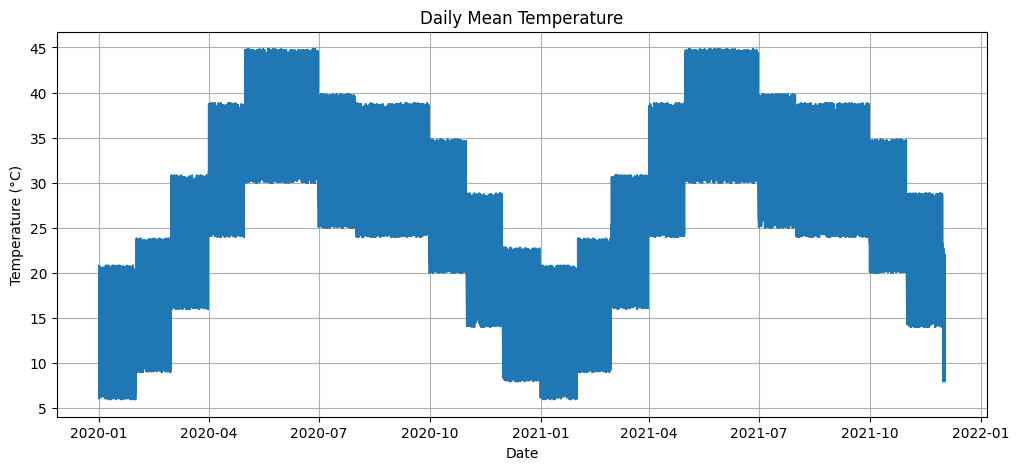

In [8]:
# Plot temperature trend
plt.figure(figsize=(12,5))
plt.plot(df["date"], df["temperature"])
plt.title("Daily Mean Temperature")
plt.xlabel("Date")
plt.ylabel("Temperature (°C)")
plt.grid(True)
plt.show()

In [16]:
# Drop rows with NaN values in the features or target variable
df_cleaned = df.dropna(subset=["humidity", "wind_speed", "temperature"])

# Convert to NumPy arrays and ensure float type for sklearn compatibility
X = df_cleaned[["humidity", "wind_speed"]].values.astype(float)
y = df_cleaned["temperature"].values.astype(float)

# Explicitly check for NaNs and Infs after conversion
import numpy as np
print(f"NaNs in X after cleanup: {np.isnan(X).sum()}")
print(f"NaNs in y after cleanup: {np.isnan(y).sum()}")
print(f"Infs in X after cleanup: {np.isinf(X).sum()}")
print(f"Infs in y after cleanup: {np.isinf(y).sum()}")

NaNs in X after cleanup: 0
NaNs in y after cleanup: 0
Infs in X after cleanup: 0
Infs in y after cleanup: 0


In [17]:
# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# Train model
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [18]:
# Predict
pred = model.predict(X_test)

# Evaluation
print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 5.189288389736753
R2 Score: 0.4991244098334968


In [22]:
# User Prediction
humidity = float(input("Humidity: "))
wind = float(input("Wind Speed: "))

result = model.predict([[humidity, wind]])

print(f"Predicted Temperature: {result[0]:.2f} °C")

Humidity: 20
Wind Speed: 80
Predicted Temperature: 100.64 °C
